In this file we will be using Kornia to have augmentations on gpu

In [2]:
import pandas as pd
import regex as re
from fastai.vision.all import *
import torch

In [3]:
df = pd.read_csv(r'D:\Traffic\labels_processed.csv')

In [4]:
def label_function(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    return class_id

In [5]:
path = Path(r'D:\Traffic\traffic_Data_processed\DATA')

In [6]:
lr_head = 0.0017378008365631102
lr_whole_model = 1.9054607491852948e-06

In [7]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
from torch.utils.data import Dataset
from PIL import Image

In [9]:
class dset(Dataset):
    def __init__(self, image_paths, transform = None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        label = label_function(Path(image_path))
        if self.transform:
            image = self.transform(image)
        return image, label

In [10]:
image_paths = list(path.rglob("*.png"))

In [11]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = dset(image_paths = image_paths, transform = transform)

In [12]:
from torch.utils.data import random_split

ts = int(0.75*len(dataset))
vs = len(dataset) - ts

generator = torch.Generator().manual_seed(42)
train_dataset, valid_dataset = random_split(dataset, [ts, vs], generator)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False
)

In [14]:
import torchvision

In [15]:
num_classes = 55

In [16]:
device = torch.device("cuda")

In [17]:
import kornia.augmentation as K

In [18]:
model_1_1 = torchvision.models.resnet34(weights="DEFAULT")
model_1_1.fc = nn.Linear(
    model_1_1.fc.in_features,
    num_classes
)

model_1_1 = model_1_1.to(device)

for param in model_1_1.parameters():
    param.requires_grad = False

for param in model_1_1.fc.parameters():
    param.requires_grad = True

train_aug = K.AugmentationSequential(
    K.RandomRotation(
        degrees = 10.0,
        p = 1.0
    )
).to(device)

optimizer_1_1 = torch.optim.RMSprop(
    model_1_1.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1_1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1_1,
    max_lr = lr_head,
    epochs = 11,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    model_1_1.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug(images)

        optimizer_1_1.zero_grad()

        outputs = model_1_1(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1_1.step()

        scheduler_1_1.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1_1.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1_1(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/11 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/11 | Train Acc: 66.59% | Valid Acc: 84.78%
Epoch 2/11 | Train Acc: 82.27% | Valid Acc: 80.35%
Epoch 3/11 | Train Acc: 83.52% | Valid Acc: 88.25%
Epoch 4/11 | Train Acc: 87.99% | Valid Acc: 84.59%
Epoch 5/11 | Train Acc: 87.21% | Valid Acc: 86.22%
Epoch 6/11 | Train Acc: 91.17% | Valid Acc: 86.71%
Epoch 7/11 | Train Acc: 91.39% | Valid Acc: 92.39%
Epoch 8/11 | Train Acc: 93.03% | Valid Acc: 92.29%
Epoch 9/11 | Train Acc: 95.09% | Valid Acc: 94.99%
Epoch 10/11 | Train Acc: 97.72% | Valid Acc: 97.01%
Epoch 11/11 | Train Acc: 99.07% | Valid Acc: 97.01%


In [20]:
model_1_2 = torchvision.models.resnet34(weights="DEFAULT")
model_1_2.fc = nn.Linear(
    model_1_2.fc.in_features,
    num_classes
)

model_1_2 = model_1_2.to(device)

for param in model_1_2.parameters():
    param.requires_grad = False

for param in model_1_2.fc.parameters():
    param.requires_grad = True

train_aug_2 = K.AugmentationSequential(
    K.ColorJiggle(
        brightness = 0.2,
        p = 1.0
    )
).to(device)

optimizer_1_2 = torch.optim.RMSprop(
    model_1_2.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1_2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1_2,
    max_lr = lr_head,
    epochs = 11,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    model_1_2.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug_2(images)

        optimizer_1_2.zero_grad()

        outputs = model_1_2(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1_2.step()

        scheduler_1_2.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1_2.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1_2(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/11 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/11 | Train Acc: 64.34% | Valid Acc: 87.57%
Epoch 2/11 | Train Acc: 83.71% | Valid Acc: 87.57%
Epoch 3/11 | Train Acc: 85.74% | Valid Acc: 89.21%
Epoch 4/11 | Train Acc: 86.86% | Valid Acc: 89.98%
Epoch 5/11 | Train Acc: 88.31% | Valid Acc: 92.77%
Epoch 6/11 | Train Acc: 89.34% | Valid Acc: 88.25%
Epoch 7/11 | Train Acc: 93.03% | Valid Acc: 94.61%
Epoch 8/11 | Train Acc: 93.16% | Valid Acc: 93.55%
Epoch 9/11 | Train Acc: 95.05% | Valid Acc: 97.21%
Epoch 10/11 | Train Acc: 97.94% | Valid Acc: 98.27%
Epoch 11/11 | Train Acc: 99.04% | Valid Acc: 97.98%


In [22]:
model_1_3 = torchvision.models.resnet34(weights="DEFAULT")
model_1_3.fc = nn.Linear(
    model_1_3.fc.in_features,
    num_classes
)

model_1_3 = model_1_3.to(device)

for param in model_1_3.parameters():
    param.requires_grad = False

for param in model_1_3.fc.parameters():
    param.requires_grad = True

train_aug_3 = K.AugmentationSequential(
    K.ColorJiggle(
        contrast = 0.2,
        p = 1.0
    )
).to(device)

optimizer_1_3 = torch.optim.RMSprop(
    model_1_3.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1_3 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1_3,
    max_lr = lr_head,
    epochs = 11,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    model_1_3.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug_3(images)

        optimizer_1_3.zero_grad()

        outputs = model_1_3(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1_3.step()

        scheduler_1_3.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1_3.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1_3(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/11 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/11 | Train Acc: 65.82% | Valid Acc: 88.82%
Epoch 2/11 | Train Acc: 85.64% | Valid Acc: 82.56%
Epoch 3/11 | Train Acc: 85.42% | Valid Acc: 85.74%
Epoch 4/11 | Train Acc: 86.15% | Valid Acc: 92.20%
Epoch 5/11 | Train Acc: 90.14% | Valid Acc: 87.96%
Epoch 6/11 | Train Acc: 92.45% | Valid Acc: 92.77%
Epoch 7/11 | Train Acc: 92.90% | Valid Acc: 93.55%
Epoch 8/11 | Train Acc: 94.38% | Valid Acc: 92.20%
Epoch 9/11 | Train Acc: 95.89% | Valid Acc: 97.11%
Epoch 10/11 | Train Acc: 98.75% | Valid Acc: 98.36%
Epoch 11/11 | Train Acc: 99.42% | Valid Acc: 98.55%


In [23]:
model_1_4 = torchvision.models.resnet34(weights="DEFAULT")
model_1_4.fc = nn.Linear(
    model_1_4.fc.in_features,
    num_classes
)

model_1_4 = model_1_4.to(device)

for param in model_1_4.parameters():
    param.requires_grad = False

for param in model_1_4.fc.parameters():
    param.requires_grad = True

train_aug_4 = K.AugmentationSequential(
    K.RandomAffine(
        degrees = 0.0,
        scale = (0.9, 1.1),
        p = 1.0
    )
).to(device)

optimizer_1_4 = torch.optim.RMSprop(
    model_1_4.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1_4 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1_4,
    max_lr = lr_head,
    epochs = 11,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    model_1_4.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug_4(images)

        optimizer_1_4.zero_grad()

        outputs = model_1_4(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1_4.step()

        scheduler_1_4.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1_4.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1_4(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/11 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/11 | Train Acc: 63.38% | Valid Acc: 84.01%
Epoch 2/11 | Train Acc: 82.72% | Valid Acc: 80.35%
Epoch 3/11 | Train Acc: 83.23% | Valid Acc: 88.63%
Epoch 4/11 | Train Acc: 86.35% | Valid Acc: 87.76%
Epoch 5/11 | Train Acc: 89.72% | Valid Acc: 91.71%
Epoch 6/11 | Train Acc: 88.21% | Valid Acc: 94.70%
Epoch 7/11 | Train Acc: 91.29% | Valid Acc: 91.81%
Epoch 8/11 | Train Acc: 92.26% | Valid Acc: 92.39%
Epoch 9/11 | Train Acc: 94.86% | Valid Acc: 96.15%
Epoch 10/11 | Train Acc: 97.72% | Valid Acc: 97.21%
Epoch 11/11 | Train Acc: 98.39% | Valid Acc: 97.59%


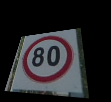

In [32]:
perspective_aug = K.AugmentationSequential(
    K.RandomPerspective(
        distortion_scale = 0.8,
        p = 1.0
    )
).to(device)

img = Image.open(r"D:\Traffic\traffic_Data_processed\DATA\7\7_1.png").convert("RGB")
img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
aug_tensor = perspective_aug(img_tensor)
aug_img = transforms.ToPILImage()(aug_tensor.squeeze(0).cpu())

aug_img

In [33]:
model_1_5 = torchvision.models.resnet34(weights="DEFAULT")
model_1_5.fc = nn.Linear(
    model_1_5.fc.in_features,
    num_classes
)

model_1_5 = model_1_5.to(device)

for param in model_1_5.parameters():
    param.requires_grad = False

for param in model_1_5.fc.parameters():
    param.requires_grad = True

train_aug_5 = K.AugmentationSequential(
    K.RandomPerspective(
        distortion_scale = 0.2,
        p = 1.0
    )
).to(device)

optimizer_1_5 = torch.optim.RMSprop(
    model_1_5.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1_5 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1_5,
    max_lr = lr_head,
    epochs = 11,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    model_1_5.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug_5(images)

        optimizer_1_5.zero_grad()

        outputs = model_1_5(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1_5.step()

        scheduler_1_5.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1_5.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1_5(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/11 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/11 | Train Acc: 64.21% | Valid Acc: 76.49%
Epoch 2/11 | Train Acc: 83.52% | Valid Acc: 49.33%
Epoch 3/11 | Train Acc: 82.75% | Valid Acc: 73.99%
Epoch 4/11 | Train Acc: 86.73% | Valid Acc: 76.30%
Epoch 5/11 | Train Acc: 88.02% | Valid Acc: 68.50%
Epoch 6/11 | Train Acc: 89.72% | Valid Acc: 71.68%
Epoch 7/11 | Train Acc: 91.13% | Valid Acc: 79.67%
Epoch 8/11 | Train Acc: 91.78% | Valid Acc: 82.08%
Epoch 9/11 | Train Acc: 94.89% | Valid Acc: 81.89%
Epoch 10/11 | Train Acc: 98.20% | Valid Acc: 85.93%
Epoch 11/11 | Train Acc: 98.72% | Valid Acc: 88.63%


In [34]:
model_1_6 = torchvision.models.resnet34(weights="DEFAULT")
model_1_6.fc = nn.Linear(
    model_1_6.fc.in_features,
    num_classes
)

model_1_6 = model_1_6.to(device)

for param in model_1_6.parameters():
    param.requires_grad = False

for param in model_1_6.fc.parameters():
    param.requires_grad = True

train_aug_6 = K.AugmentationSequential(
    K.RandomGaussianBlur(
        kernel_size = (3, 3),
        sigma = (0.1, 2.0),
        p = 1.0
    )
).to(device)

optimizer_1_6 = torch.optim.RMSprop(
    model_1_6.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1_6 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1_6,
    max_lr = lr_head,
    epochs = 11,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    model_1_6.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug_6(images)

        optimizer_1_6.zero_grad()

        outputs = model_1_6(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1_6.step()

        scheduler_1_6.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1_6.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1_6(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/11 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/11 | Train Acc: 66.37% | Valid Acc: 82.08%
Epoch 2/11 | Train Acc: 85.29% | Valid Acc: 85.65%
Epoch 3/11 | Train Acc: 86.12% | Valid Acc: 88.15%
Epoch 4/11 | Train Acc: 89.40% | Valid Acc: 90.17%
Epoch 5/11 | Train Acc: 89.82% | Valid Acc: 93.55%
Epoch 6/11 | Train Acc: 91.65% | Valid Acc: 92.58%
Epoch 7/11 | Train Acc: 92.74% | Valid Acc: 90.75%
Epoch 8/11 | Train Acc: 95.05% | Valid Acc: 95.28%
Epoch 9/11 | Train Acc: 96.21% | Valid Acc: 97.01%
Epoch 10/11 | Train Acc: 98.68% | Valid Acc: 97.11%
Epoch 11/11 | Train Acc: 99.42% | Valid Acc: 97.50%


In [35]:
model_1_7 = torchvision.models.resnet34(weights="DEFAULT")
model_1_7.fc = nn.Linear(
    model_1_7.fc.in_features,
    num_classes
)

model_1_7 = model_1_7.to(device)

for param in model_1_7.parameters():
    param.requires_grad = False

for param in model_1_7.fc.parameters():
    param.requires_grad = True

train_aug_7 = K.AugmentationSequential(
    K.RandomResizedCrop(
        size = (224, 224),
        scale = (0.8, 1.0),
        p = 1.0
    )
).to(device)

optimizer_1_7 = torch.optim.RMSprop(
    model_1_7.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1_7 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1_7,
    max_lr = lr_head,
    epochs = 11,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    model_1_7.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug_7(images)

        optimizer_1_7.zero_grad()

        outputs = model_1_7(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1_7.step()

        scheduler_1_7.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1_7.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1_7(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/11 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/11 | Train Acc: 64.73% | Valid Acc: 85.65%
Epoch 2/11 | Train Acc: 83.52% | Valid Acc: 81.50%
Epoch 3/11 | Train Acc: 85.26% | Valid Acc: 88.73%
Epoch 4/11 | Train Acc: 87.21% | Valid Acc: 89.69%
Epoch 5/11 | Train Acc: 90.14% | Valid Acc: 83.72%
Epoch 6/11 | Train Acc: 90.56% | Valid Acc: 91.23%
Epoch 7/11 | Train Acc: 92.19% | Valid Acc: 91.52%
Epoch 8/11 | Train Acc: 92.39% | Valid Acc: 92.39%
Epoch 9/11 | Train Acc: 96.11% | Valid Acc: 96.53%
Epoch 10/11 | Train Acc: 97.21% | Valid Acc: 97.11%
Epoch 11/11 | Train Acc: 98.97% | Valid Acc: 97.98%


In [36]:
model_1_8 = torchvision.models.resnet34(weights="DEFAULT")
model_1_8.fc = nn.Linear(
    model_1_8.fc.in_features,
    num_classes
)

model_1_8 = model_1_8.to(device)

for param in model_1_8.parameters():
    param.requires_grad = False

for param in model_1_8.fc.parameters():
    param.requires_grad = True

train_aug_8 = K.AugmentationSequential(
    K.RandomErasing(
        scale = (0.02, 0.2),
        ratio = (0.3, 3.3),
        p = 1.0
    )
).to(device)

optimizer_1_8 = torch.optim.RMSprop(
    model_1_8.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1_8 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1_8,
    max_lr = lr_head,
    epochs = 11,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    model_1_8.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug_8(images)

        optimizer_1_8.zero_grad()

        outputs = model_1_8(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1_8.step()

        scheduler_1_8.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1_8.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1_8(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/11 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/11 | Train Acc: 47.03% | Valid Acc: 79.87%
Epoch 2/11 | Train Acc: 71.09% | Valid Acc: 82.56%
Epoch 3/11 | Train Acc: 71.06% | Valid Acc: 81.12%
Epoch 4/11 | Train Acc: 73.59% | Valid Acc: 79.96%
Epoch 5/11 | Train Acc: 76.45% | Valid Acc: 88.73%
Epoch 6/11 | Train Acc: 78.51% | Valid Acc: 89.11%
Epoch 7/11 | Train Acc: 82.17% | Valid Acc: 91.04%
Epoch 8/11 | Train Acc: 83.81% | Valid Acc: 92.00%
Epoch 9/11 | Train Acc: 86.67% | Valid Acc: 91.62%
Epoch 10/11 | Train Acc: 90.81% | Valid Acc: 96.05%
Epoch 11/11 | Train Acc: 93.64% | Valid Acc: 96.24%


In [37]:
import kornia
kornia.__version__

'0.8.2'

In [40]:
mixup = K.RandomMixUpV2(
    lambda_val = None,
    p = 1.0
).to(device)

In [42]:
imgs, lbls = dataset[0]

In [47]:
mixed = mixup(imgs, lbls)

In [48]:
type(mixup(imgs, lbls))

torch.Tensor

In [49]:
type(mixed), type(mixup)

(torch.Tensor, kornia.augmentation._2d.mix.mixup.RandomMixUpV2)

In [50]:
mixed.shape, mixed.dtype

(torch.Size([1, 3, 224, 224]), torch.float32)

In [51]:
type(lbls), type(imgs)

(int, torch.Tensor)

In [53]:
print(lbls)

0


In [ ]:
model_1_9 = torchvision.models.resnet34(weights="DEFAULT")
model_1_9.fc = nn.Linear(
    model_1_9.fc.in_features,
    num_classes
)

model_1_9 = model_1_9.to(device)

for param in model_1_9.parameters():
    param.requires_grad = False

for param in model_1_9.fc.parameters():
    param.requires_grad = True

train_aug_9 = K.RandomMixUpV2(
    lambda_val = None,
    p = 1.0
).to(device)

optimizer_1_9 = torch.optim.RMSprop(
    model_1_9.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1_9 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1_9,
    max_lr = lr_head,
    epochs = 11,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(11):
    model_1_9.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images, labels = train_aug_9(images, labels)

        optimizer_1_9.zero_grad()

        outputs = model_1_9(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1_9.step()

        scheduler_1_9.step()          

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    model_1_9.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1_9(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/11 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )